# Logistic Regression for Just-In-Time Bug Prediction

## Objective

This experiment evaluates Logistic Regression as a baseline model for
predicting defect-inducing commits.

A time-aware evaluation strategy is adopted to simulate real-world
software development scenarios where future commits are unknown during training.

The model is evaluated using Accuracy, Precision, Recall, F1 Score,
and ROC-AUC.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/data/processed_data.csv"
)

df.head()

,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp,buggy
0,1063292086,58,0,1,1,1,0.0,1.0,0.0,1.0,10,10.0,6.0,0
1,1063292137,78,0,1,1,1,0.0,0.0,0.0,0.0,21,21.0,1.0,0
2,1063292285,2,3,1,1,1,0.0,2.0,0.0,2.0,11,11.0,7.0,0
3,1063292362,2,0,1,1,1,0.0,2.0,0.0,3.0,12,12.0,8.0,0
4,1063292625,33,0,1,1,1,0.0,1.0,0.0,1.0,13,13.0,9.0,0


## Dataset Overview

The processed dataset contains commit-level software metrics and
binary labels indicating whether a commit is bug-inducing.

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (106674, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   author_date  106674 non-null  int64  
 1   la           106674 non-null  int64  
 2   ld           106674 non-null  int64  
 3   nf           106674 non-null  int64  
 4   nd           106674 non-null  int64  
 5   ns           106674 non-null  int64  
 6   ent          106674 non-null  float64
 7   ndev         106674 non-null  float64
 8   age          106674 non-null  float64
 9   nuc          106674 non-null  float64
 10  aexp         106674 non-null  int64  
 11  arexp        106674 non-null  float64
 12  asexp        106674 non-null  float64
 13  buggy        106674 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 11.4 MB


## Feature Matrix and Target Variable

The selected JIT metrics represent:

- Code churn
- Change complexity
- Developer experience
- Historical modification patterns

In [5]:
features = [

    'la',
    'ld',
    'nf',
    'nd',
    'ns',
    'ent',
    'ndev',
    'age',
    'nuc',
    'aexp',
    'arexp',
    'asexp'
]

X = df[features]

y = df['buggy']

## Time-Aware Train-Test Split

Commits are already sorted chronologically during preprocessing.

The oldest 80% of commits are used for training while the newest
20% are reserved for testing.

In [6]:
split_index = int(len(df)*0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

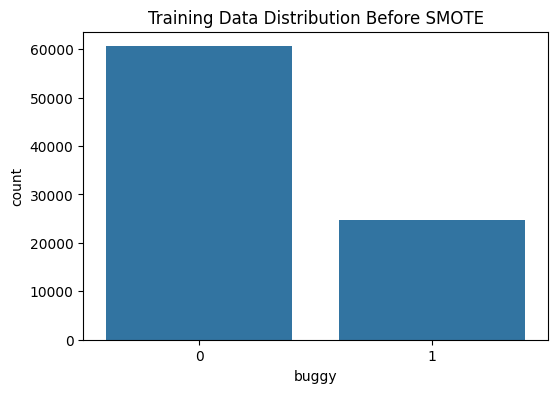

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Data Distribution Before SMOTE")

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/lr_before_smote.png",
    bbox_inches="tight"
)

plt.show()

## Handling Class Imbalance

Software defect datasets are typically imbalanced.

SMOTE is applied only to the training set to generate synthetic
minority class examples and improve learning.

In [8]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

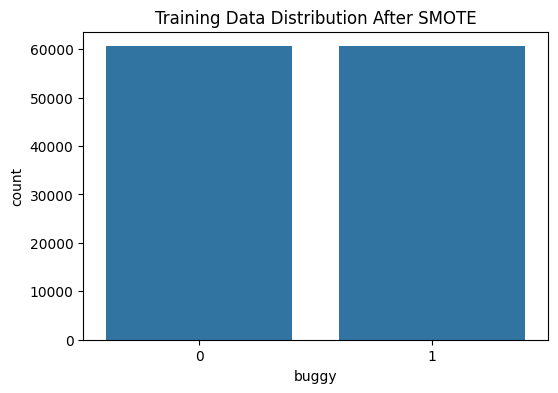

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_resampled)

plt.title("Training Data Distribution After SMOTE")

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/lr_after_smote.png",
    bbox_inches="tight"
)

plt.show()

## Feature Scaling

Logistic Regression performs best when numerical features are standardized.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_resampled
)

X_test_scaled = scaler.transform(
    X_test
)

## Model Training

Logistic Regression is used as the baseline classifier.

The maximum number of iterations is increased to ensure convergence.

In [11]:
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train_resampled
)

LogisticRegression(max_iter=5000, random_state=42)

In [12]:
lr_pred = lr_model.predict(
    X_test_scaled
)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

In [13]:
accuracy = accuracy_score(y_test, lr_pred)

precision = precision_score(y_test, lr_pred)

recall = recall_score(y_test, lr_pred)

f1 = f1_score(y_test, lr_pred)

roc_auc = roc_auc_score(y_test, lr_prob)

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Value
0,Accuracy,0.692383
1,Precision,0.304552
2,Recall,0.686443
3,F1 Score,0.421915
4,ROC AUC,0.761170


In [14]:
results.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/logistic_metrics.csv",
    index=False
)

In [15]:
report = classification_report(
    y_test,
    lr_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.918789,0.693545,0.790433,17846.000000
1,0.304552,0.686443,0.421915,3489.000000
accuracy,0.692383,0.692383,0.692383,0.692383
macro avg,0.611670,0.689994,0.606174,21335.000000
weighted avg,0.818340,0.692383,0.730168,21335.000000


In [16]:
report_df.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/logistic_classification_report.csv"
)

## Confusion Matrix Analysis

The confusion matrix provides insight into
correct and incorrect predictions.

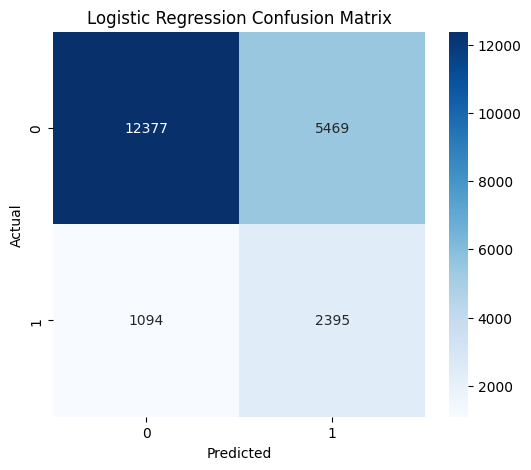

In [17]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/logistic_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

## ROC Curve

The ROC curve illustrates the trade-off between
True Positive Rate and False Positive Rate.

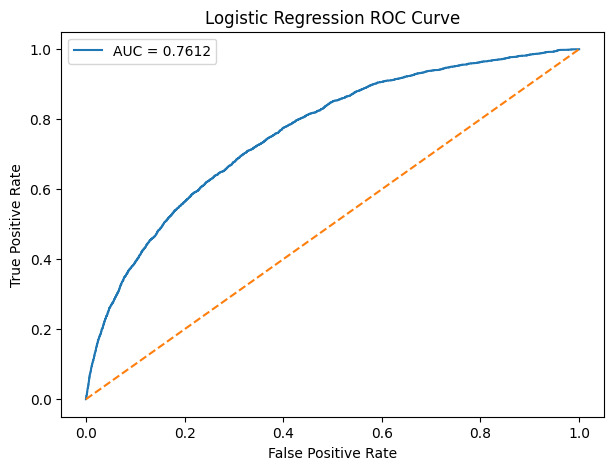

In [18]:
fpr, tpr, _ = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/logistic_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
coef_df = pd.DataFrame({

    "Feature":features,

    "Coefficient":
    lr_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
0,la,0.785749
5,ent,0.631240
8,nuc,0.286706
4,ns,0.276001
11,asexp,0.079423
10,arexp,0.071180
1,ld,-0.049927
7,age,-0.085008
2,nf,-0.134677
3,nd,-0.147262


In [20]:
coef_df.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/logistic_coefficients.csv",
    index=False
)

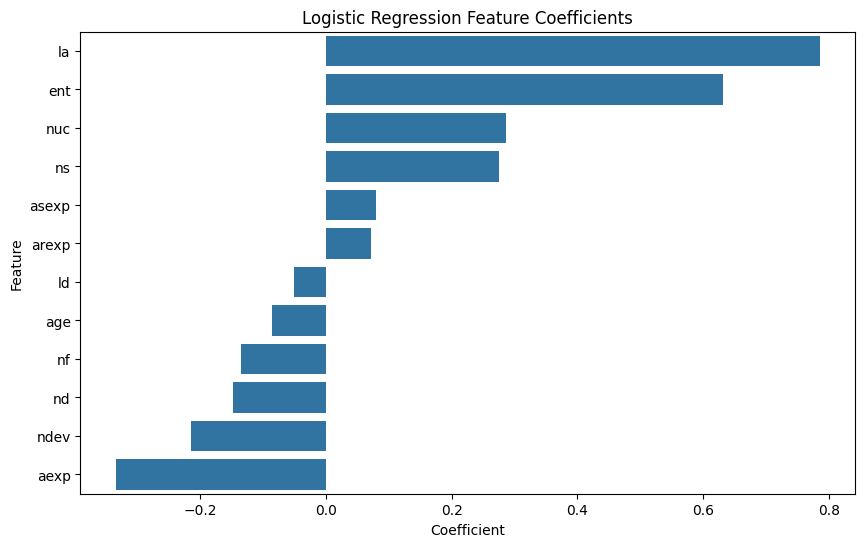

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Logistic Regression Feature Coefficients"
)

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/logistic_coefficients.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
joblib.dump(
    lr_model,
    "/content/drive/MyDrive/JIT_bug_prediction/models/logistic_regression.pkl"
)

['/content/drive/MyDrive/JIT_bug_prediction/models/logistic_regression.pkl']

In [24]:
joblib.dump(
    scaler,
    "/content/drive/MyDrive/JIT_bug_prediction/models/logistic_scaler.pkl"
)

['/content/drive/MyDrive/JIT_bug_prediction/models/logistic_scaler.pkl']

# Findings

## Logistic Regression Performance

| Metric | Value |
|----------|----------|
| Accuracy | 69.24% |
| Precision | 30.46% |
| Recall | 68.64% |
| F1 Score | 42.19% |
| ROC-AUC | 0.7612 |

---

## Interpretation of Results

Logistic Regression was used as the baseline model for predicting
defect-inducing commits in the ApacheJIT dataset.

The model achieved a Recall of 68.64%, indicating that it successfully
identified a large proportion of buggy commits. This is particularly
important in software defect prediction, where failing to detect a bug
can lead to higher maintenance costs and reduced software reliability.

The Precision of 30.46% indicates that a significant number of commits
predicted as buggy were actually non-buggy. This suggests that the model
generates false alarms, which is a common trade-off when using SMOTE to
handle class imbalance.

The ROC-AUC score of 0.7612 demonstrates that the model has a good
ability to distinguish between buggy and non-buggy commits and provides
a strong baseline for comparison with more advanced machine learning
models.

---

## Class-wise Performance

### Non-Buggy Commits (Class 0)

- Precision: 91.88%
- Recall: 69.35%
- F1 Score: 79.04%

The model performs well in identifying non-buggy commits.

### Buggy Commits (Class 1)

- Precision: 30.46%
- Recall: 68.64%
- F1 Score: 42.19%

The model successfully captures most buggy commits but produces a
considerable number of false positives.

---

## Overall Conclusion

Logistic Regression provides a reliable baseline model for the
Just-In-Time Bug Prediction task.

Key observations:

- Good defect detection capability (high recall).
- Reasonable discriminatory power (ROC-AUC = 0.7612).
- Lower precision due to false positive predictions.
- Suitable as a baseline model for comparison against more advanced
  algorithms.

Future experiments using Random Forest and XGBoost are expected to
improve precision, F1-score, and overall predictive performance by
capturing non-linear relationships among software metrics.